# Домашнее задание. Урок 26. Библиотека Seaborn

По условию требуется повторить графики из предыдущего домашнего задания,
но средствами seaborn вместо matplotlib:

1. столбчатая диаграмма — выручка по категориям фильмов;
2. гистограмма — распределение суммы платежей на одного клиента;
3. точечная диаграмма — длительность фильма и принесённая им выручка;
4. тепловая карта — количество фильмов по категориям и возрастным рейтингам.

Данные те же, выгруженные из базы dvdrental в подпапку `data`. Это удобно:
исходные данные и выводы не меняются, поэтому хорошо видно, что именно
даёт переход на seaborn.

К каждому графику приведены выводы, а также отмечено, чем построение
на seaborn отличается от matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Единое оформление для всех графиков задаётся одной строкой.
# В matplotlib пришлось бы настраивать сетку, фон и шрифты вручную
# на каждом графике.
sns.set_theme(style="whitegrid")

print("seaborn   :", sns.__version__)
print("matplotlib:", matplotlib.__version__)

seaborn   : 0.13.2
matplotlib: 3.11.0


## Загрузка и подготовка данных

In [2]:
film          = pd.read_csv("data/film.csv")
film_category = pd.read_csv("data/film_category.csv")
category      = pd.read_csv("data/category.csv")
inventory     = pd.read_csv("data/inventory.csv")
rental        = pd.read_csv("data/rental.csv")
payment       = pd.read_csv("data/payment.csv")

film_money = (
    payment[["payment_id", "rental_id", "amount"]]
    .merge(rental[["rental_id", "inventory_id"]], on="rental_id", how="inner")
    .merge(inventory[["inventory_id", "film_id"]], on="inventory_id", how="inner")
    .merge(film[["film_id", "title", "length", "rating"]], on="film_id", how="inner")
    .merge(film_category[["film_id", "category_id"]], on="film_id", how="inner")
    .merge(category[["category_id", "name"]], on="category_id", how="inner")
    .rename(columns={"name": "category"})
)

print("Строк в объединённой таблице:", film_money.shape[0])
film_money.head()

Строк в объединённой таблице: 14596


,payment_id,rental_id,amount,inventory_id,film_id,title,length,rating,category_id,category
0,17503,1520,7.99,3419,749,Rules Human,153,R,11,Horror
1,17504,1778,1.99,2512,552,Majestic Floats,130,PG,6,Documentary
2,17505,1849,7.99,2507,551,Maiden Home,138,PG,13,New
3,17506,2829,2.99,2047,445,Hyde Doctor,100,G,4,Classics
4,17507,3130,7.99,2569,563,Massacre Usual,165,R,10,Games


## График 1. Столбчатая диаграмма — выручка по категориям

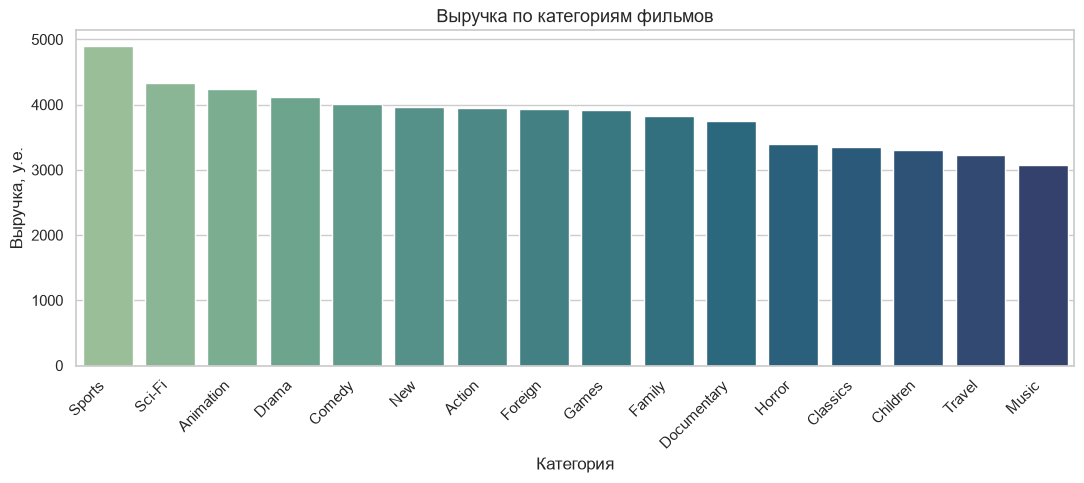

In [3]:
revenue_by_category = (
    film_money
    .groupby("category", as_index=False)
    .agg(revenue=("amount", "sum"))
    .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(11, 5))

sns.barplot(data=revenue_by_category,
            x="category", y="revenue",
            hue="category", palette="crest", legend=False)

plt.title("Выручка по категориям фильмов", fontsize=13)
plt.xlabel("Категория")
plt.ylabel("Выручка, у.е.")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Выводы по графику 1

Разброс между жанрами невелик: лидер приносит примерно в 1,6 раза больше
аутсайдера при шестнадцати категориях. Ни один жанр не является определяющим
для выручки.

Практический вывод обратный тому, что обычно ищут в таком графике. Раз выручка
распределена по жанрам почти равномерно, отказ от нижних категорий отрезал бы
заметную долю выручки, не дав ничего взамен. Разницу между соседними столбцами
стоит считать шумом; значимо только сравнение верхних категорий с нижними.

### Чем отличается построение на seaborn

`sns.barplot` принимает датафрейм целиком и сам сопоставляет колонки осям.
В matplotlib значения для осей передавались двумя отдельными массивами.

Цветовая схема задаётся одним параметром `palette`, тогда как в matplotlib
цвет указывался кодом вручную. Обратите внимание на параметр `hue="category"`
вместе с `legend=False`: в новых версиях seaborn раскраска по категориям
требует явного указания, по какой переменной красить, а легенда здесь лишняя,
поскольку названия уже подписаны на оси.

## График 2. Гистограмма — распределение суммы платежей на клиента

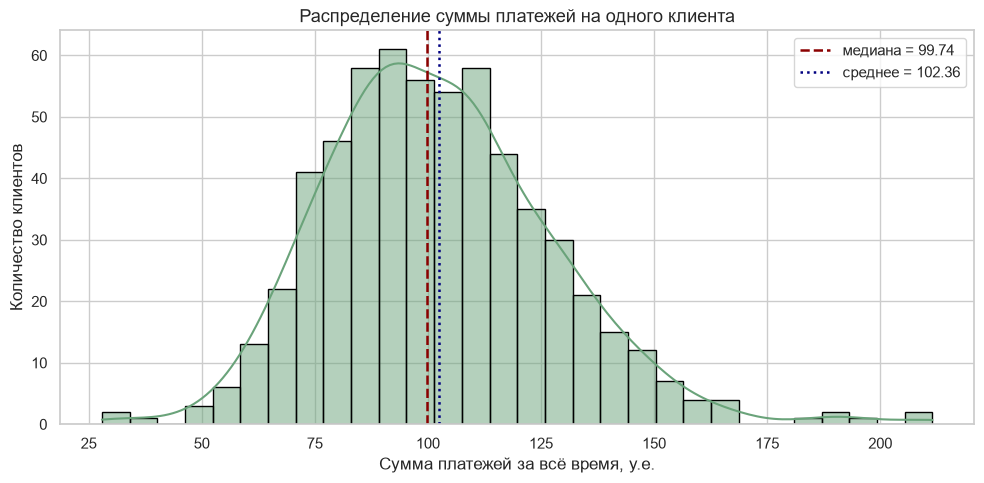

In [4]:
customer_total = (
    payment
    .groupby("customer_id", as_index=False)
    .agg(total_amount=("amount", "sum"))
)
customer_total["total_amount"] = customer_total["total_amount"].round(2)

median_value = customer_total["total_amount"].median()
mean_value = customer_total["total_amount"].mean()

plt.figure(figsize=(10, 5))

sns.histplot(data=customer_total, x="total_amount",
             bins=30, color="#6aa37a", edgecolor="black", kde=True)

plt.axvline(median_value, color="darkred", linestyle="--", linewidth=1.8,
            label=f"медиана = {median_value:.2f}")
plt.axvline(mean_value, color="navy", linestyle=":", linewidth=1.8,
            label=f"среднее = {mean_value:.2f}")

plt.title("Распределение суммы платежей на одного клиента", fontsize=13)
plt.xlabel("Сумма платежей за всё время, у.е.")
plt.ylabel("Количество клиентов")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
print(customer_total["total_amount"].describe().round(2).to_string())

count    599.00
mean     102.36
std       25.23
min       27.93
25%       85.77
50%       99.74
75%      117.24
max      211.55


### Выводы по графику 2

Распределение одновершинное и близко к симметричному: основная масса клиентов
сосредоточена в середине диапазона, крайние значения редки. Среднее и медиана
расположены рядом, что прямо следует из симметричности.

Для клиентских данных такая картина нетипична. Обычно выручка имеет сильный
правый хвост, когда небольшая группа клиентов приносит непропорционально много.
Здесь хвоста нет, и это говорит скорее об искусственном происхождении учебных
данных, чем о свойствах реального бизнеса.

Отсюда практический вывод: выраженной группы «крупных клиентов» не существует,
поэтому любая сегментация по сумме платежей разрежет плотную середину
распределения, а не отделит естественно обособленную группу.

### Чем отличается построение на seaborn

Добавлен параметр `kde=True` — поверх столбцов рисуется сглаженная оценка
плотности. Это удобно именно здесь: по гистограмме форму распределения
приходится угадывать по высоте столбцов, а сглаженная кривая показывает её
напрямую и сразу подтверждает, что вершина одна.

В matplotlib такую кривую пришлось бы считать отдельно и накладывать вручную.

## График 3. Точечная диаграмма — длительность фильма и его выручка

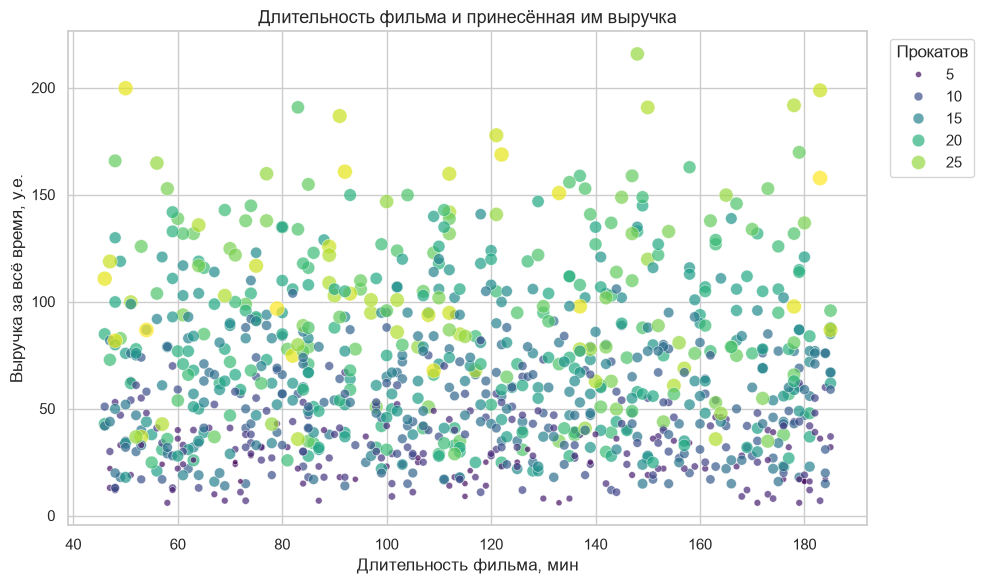

In [6]:
film_stats = (
    film_money
    .groupby(["film_id", "title", "rating"], as_index=False)
    .agg(revenue=("amount", "sum"), rentals=("payment_id", "count"))
    .merge(film[["film_id", "length"]], on="film_id", how="inner")
)
film_stats["revenue"] = film_stats["revenue"].round(2)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=film_stats, x="length", y="revenue",
                size="rentals", hue="rentals",
                palette="viridis", sizes=(15, 120), alpha=0.7)

plt.title("Длительность фильма и принесённая им выручка", fontsize=13)
plt.xlabel("Длительность фильма, мин")
plt.ylabel("Выручка за всё время, у.е.")
plt.legend(title="Прокатов", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
print(f"длительность и выручка : {film_stats['length'].corr(film_stats['revenue']):+.3f}")
print(f"длительность и прокаты : {film_stats['length'].corr(film_stats['rentals']):+.3f}")
print(f"прокаты и выручка      : {film_stats['rentals'].corr(film_stats['revenue']):+.3f}")

длительность и выручка : -0.008
длительность и прокаты : -0.034
прокаты и выручка      : +0.635


### Выводы по графику 3

Облако точек не имеет направления: при любой длительности встречаются фильмы
и с высокой, и с низкой выручкой. Коэффициент корреляции близок к нулю,
что подтверждает увиденное.

Длительность фильма не объясняет его выручку. Гипотеза, с которой строился
график, не подтвердилась, и это полноценный результат: если бы требовалось
предсказывать выручку, поле `length` как признак брать не стоило бы.

Зато цвет и размер точек показывают то, чего не было видно в версии на matplotlib:
точки выстраиваются по градиенту снизу вверх — чем чаще фильм брали,
тем больше он принёс. Корреляция числа прокатов с выручкой равна 0,64,
то есть связь заметная, но не полная.

Это само по себе любопытно: казалось бы, выручка должна определяться числом
прокатов однозначно. Неполнота связи объясняется тем, что фильмы различаются
по стоимости проката, поэтому одинаковое число выдач даёт разную выручку.

### Чем отличается построение на seaborn

Здесь разница самая заметная. Параметры `hue` и `size` добавили на график
третью переменную — число прокатов — сразу и цветом, и размером точки.
Легенда с подписями построена автоматически.

В matplotlib пришлось бы вручную нормировать значения в диапазон размеров,
подбирать цветовую шкалу и собирать легенду по частям. Именно за такие вещи
seaborn и берут, когда на одном графике нужно показать больше двух измерений.

## График 4. Тепловая карта — категория и возрастной рейтинг

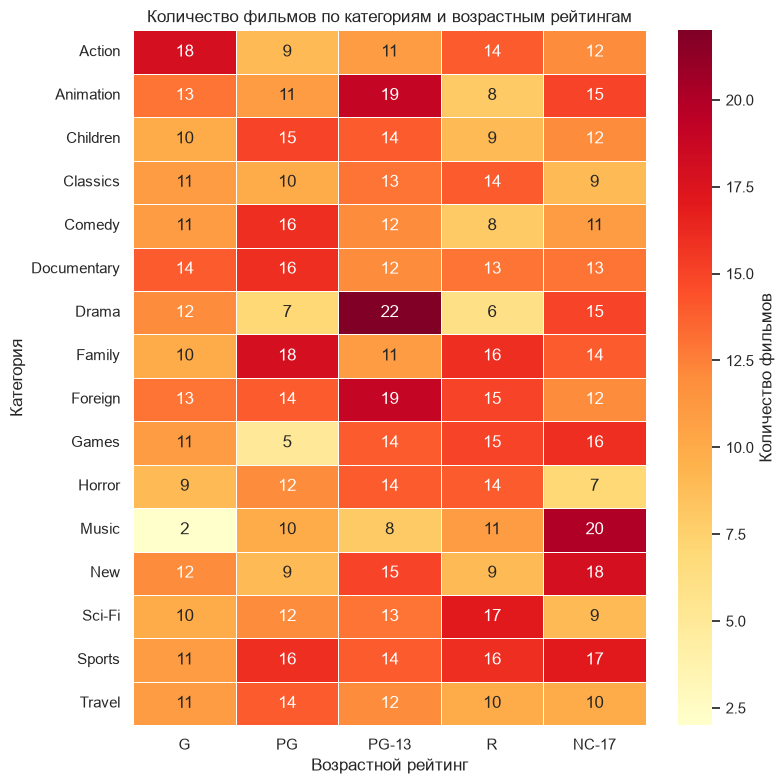

In [8]:
films_with_category = (
    film[["film_id", "rating"]]
    .merge(film_category[["film_id", "category_id"]], on="film_id", how="inner")
    .merge(category[["category_id", "name"]], on="category_id", how="inner")
    .rename(columns={"name": "category"})
)

matrix = pd.pivot_table(films_with_category, index="category", columns="rating",
                        values="film_id", aggfunc="count", fill_value=0)

rating_order = ["G", "PG", "PG-13", "R", "NC-17"]
matrix = matrix[rating_order]

plt.figure(figsize=(8, 8))

sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Количество фильмов"})

plt.title("Количество фильмов по категориям и возрастным рейтингам", fontsize=12)
plt.xlabel("Возрастной рейтинг")
plt.ylabel("Категория")
plt.tight_layout()
plt.show()

In [9]:
values = matrix.values
print("Ячеек в матрице       :", values.size)
print("Минимум / максимум    :", values.min(), "/", values.max())
print("Среднее на ячейку     :", round(values.mean(), 2))
print("Стандартное отклонение:", round(values.std(), 2))
print("Корень из среднего    :", round(np.sqrt(values.mean()), 2))
print()
print("Фильмов по рейтингам:")
print(matrix.sum(axis=0).sort_values(ascending=False).to_string())

Ячеек в матрице       : 80
Минимум / максимум    : 2 / 22
Среднее на ячейку     : 12.5
Стандартное отклонение: 3.51
Корень из среднего    : 3.54

Фильмов по рейтингам:
rating
PG-13    223
NC-17    210
R        195
PG       194
G        178


### Выводы по графику 4

Отдельные ячейки заметно различаются — от 2 фильмов в сочетании «Music и G»
до 22 в сочетании «Drama и PG-13». Но прежде чем видеть в этом структуру,
стоит проверить, отличается ли разброс от случайного.

Тысяча фильмов распределена по 80 ячейкам, то есть в среднем по 12,5
на ячейку. Фактическое стандартное отклонение равно 3,5 — ровно столько
и ожидается при чисто случайном распределении такого количества объектов.
Значит, различия объясняются случайностью, а не связью жанра с рейтингом.

Суммы по рейтингам это подтверждают: от 178 до 223 фильмов на каждый
из пяти, перекоса нет.

Для реального каталога такая картина невозможна: в категории Children
числится 12 фильмов с рейтингом NC-17. Это прямое указание на то, что
рейтинги в учебной базе проставлены случайно.

### Чем отличается построение на seaborn

Здесь разница в объёме кода. `sns.heatmap` сам подписывает оси названиями
строк и столбцов датафрейма, сам рисует цветовую шкалу с заголовком и сам
проставляет значения внутри ячеек по параметру `annot=True`.

В версии на matplotlib подписи значений пришлось расставлять циклом по всем
восьмидесяти ячейкам, отдельно подбирая цвет текста, чтобы он читался
и на светлом, и на тёмном фоне. Seaborn делает это сам.

## Общий вывод

Все четыре графика из предыдущего задания воспроизведены средствами seaborn.
Выводы по данным не изменились, и это ожидаемо — данные те же, менялся только
инструмент построения.

Что дал переход на seaborn:

- единое оформление всех графиков задаётся одной строкой `set_theme`;
- библиотека работает с датафреймом напрямую, без ручной подготовки массивов;
- дополнительные измерения добавляются параметрами `hue` и `size`, легенда
  строится сама;
- служебная работа вроде подписей ячеек тепловой карты выполняется
  автоматически.

Где matplotlib остаётся нужен: вертикальные линии медианы и среднего
на гистограмме рисовались через `plt.axvline`, а заголовки и подписи осей —
обычными вызовами matplotlib. Seaborn построен поверх matplotlib и не заменяет
его, а избавляет от рутины в типовых случаях.